In [30]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # this makes a dummy  dataset for us
import pandas as pd
import numpy as np
%matplotlib inline 

In [31]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    centers=3,
    n_features=2,
    random_state=23
)

In [32]:
X.shape

(1000, 2)

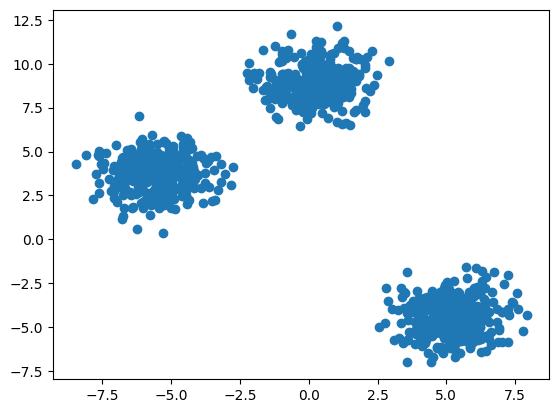

In [33]:
plt.scatter(X[:,0],X[:,1])

In [34]:
from sklearn.model_selection import train_test_split
x_train,  x_test , y_train , y_test= train_test_split(X ,y ,test_size=0.2,random_state=2,stratify=y)

In [35]:
from sklearn.cluster import KMeans

In [36]:
# now we are finding k value? 
# manual method 
# elbow method

wcss=[]
for k in range(1,11):
    Kmeans=KMeans(n_clusters=k, init='k-means++')

    Kmeans.fit(x_train)
    wcss.append(Kmeans.inertia_)

In [37]:
wcss

[40806.010430815375,
 9683.544159173916,
 1551.3815531684954,
 1376.6838285750164,
 1202.967066344589,
 1081.9812421893876,
 907.9163950327392,
 876.3623935802938,
 758.4170239379611,
 656.6638023916851]

<function matplotlib.pyplot.show(close=None, block=None)>

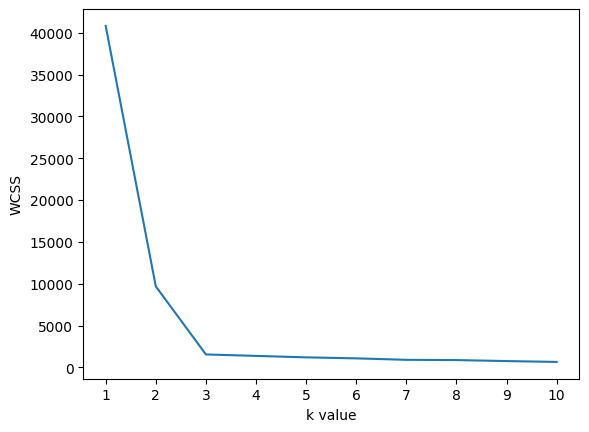

In [38]:
#plotting the elbow
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('k value')
plt.ylabel('WCSS')
plt.show

so this shows that the elbow is at 3 which is a stable point then

In [39]:
# so now final values are 

model=KMeans(n_clusters=3, init='k-means++')

y_labels=model.fit_predict(x_train)

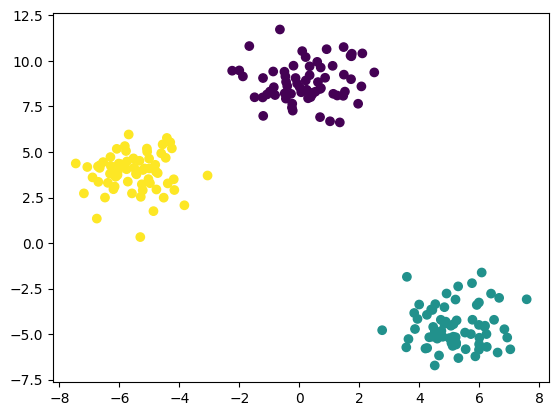

In [44]:

y_test_labels=model.predict(x_test)

plt.scatter(x_test[:,0],x_test[:,1], c=y_test_labels)

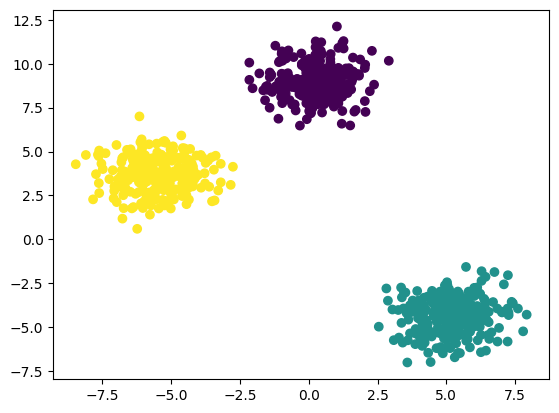

In [42]:
plt.scatter(x_train[:,0],x_train[:,1], c=y_labels)

In [46]:
# here we done everything manually 
# so for this we can use  a library called KNEE LOCATOR

!pip install kneed


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from kneed import KneeLocator

kl=KneeLocator(range(1,11), wcss , curve='convex', direction='decreasing')# convex is used when the value is decreasing
kl.elbow

np.int64(3)

In [50]:
# performance validation we use seloid score

from sklearn.metrics import silhouette_score


In [51]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [52]:
silhouette_coefficients

[0.7233327076843956,
 0.8079862061259628,
 0.6488722195256106,
 0.484587024294711,
 0.4977155889547474,
 0.47917480575365673,
 0.31775182108532074,
 0.34575080732979946,
 0.33834676949797526]